# Gold Layer - Finance Credit Forecast Report

**Stakeholder:** Finance<br>
**Question:** What will our total credit liability exposure be next quarter, by service tier?

In [1]:
import pandas as pd

In [2]:
final_df = pd.read_csv('sample_data/output/final_shipments.csv')
final_df['booking_timestamp'] = pd.to_datetime(final_df['booking_timestamp'])
final_df['quarter'] = final_df['booking_timestamp'].dt.to_period('Q')
final_df.head()

,shipment_id,booking_timestamp,promised_delivery_date,region,customer_type,service_tier,is_guaranteed,weight_kg,fda,first_attempt_date,actual_delivery_date,invoice_date,base_rate,fuel_surcharge_pct,fuel_surcharge_amount,guarantee_fee,total_billed,is_breached,credit_liability,quarter
0,SHP-00000000,2011-07-13 08:40:56.139636,2011-07-16,Atlantic,RESIDENTIAL,GROUND,False,3.62,1.0,2011-07-14,2011-07-14,2011-07-14,8.00,0.1478,1.18,0.0,9.18,False,0.0,2011Q3
1,SHP-00000001,2011-07-13 17:52:54.265014,2011-07-16,Calgary-Edmonton,RESIDENTIAL,GROUND,False,23.23,1.0,2011-07-14,2011-07-14,2011-07-14,27.88,0.1478,4.12,0.0,32.00,False,0.0,2011Q3
2,SHP-00000002,2011-07-13 16:58:01.421036,2011-07-16,GTA,COMMERCIAL,GROUND,False,18.53,1.0,2011-07-14,2011-07-14,2011-07-14,22.24,0.1478,3.29,0.0,25.53,False,0.0,2011Q3
3,SHP-00000003,2011-07-13 07:07:17.617848,2011-07-16,GTA,RESIDENTIAL,GROUND,False,24.06,0.0,2011-07-14,2011-07-15,2011-07-13,28.87,0.1478,4.27,0.0,33.14,False,0.0,2011Q3
4,SHP-00000004,2011-07-13 09:43:06.971432,2011-07-13,Montreal,RESIDENTIAL,SAME_DAY,False,1.71,0.0,2011-07-13,2011-07-15,2011-07-13,25.00,0.1478,3.69,0.0,28.69,True,0.0,2011Q3


## Quarterly Grain Analysis

Builds the Gold aggregation at quarterly grain and evaluates four forecasting models for total
credit liability, per service tier.

In [3]:
gold_df = final_df.groupby(['quarter','service_tier']).agg(
    total_shipments=('shipment_id', 'count'),
    total_credit_liability=('credit_liability', 'sum'),
    breach_rate=('is_breached', lambda x: x.fillna(False).mean()),
    guarantee_attach_rate=('is_guaranteed', 'mean'),
    avg_fda_rate=('fda', 'mean'),
    total_billed=('total_billed', 'sum'),
).reset_index()

gold_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed
0,2011Q3,EXPRESS,2158,981.820,0.133457,0.261353,0.822408,51315.98
1,2011Q3,GROUND,6616,512.135,0.029625,0.179565,0.806178,129841.60
2,2011Q3,SAME_DAY,725,851.445,0.202759,0.343448,0.810249,23696.24
3,2011Q4,EXPRESS,2664,1439.590,0.148649,0.262012,0.813515,63823.41
4,2011Q4,GROUND,8875,424.645,0.029183,0.181972,0.799277,174885.79
...,...,...,...,...,...,...,...,...
178,2026Q2,GROUND,17723,1258.990,0.029453,0.181346,0.804878,504892.25
179,2026Q2,SAME_DAY,1985,3162.590,0.216625,0.332494,0.806468,91411.21
180,2026Q3,EXPRESS,832,543.975,0.145433,0.248798,0.761733,28278.88
181,2026Q3,GROUND,2570,222.940,0.022957,0.180545,0.747171,72970.27


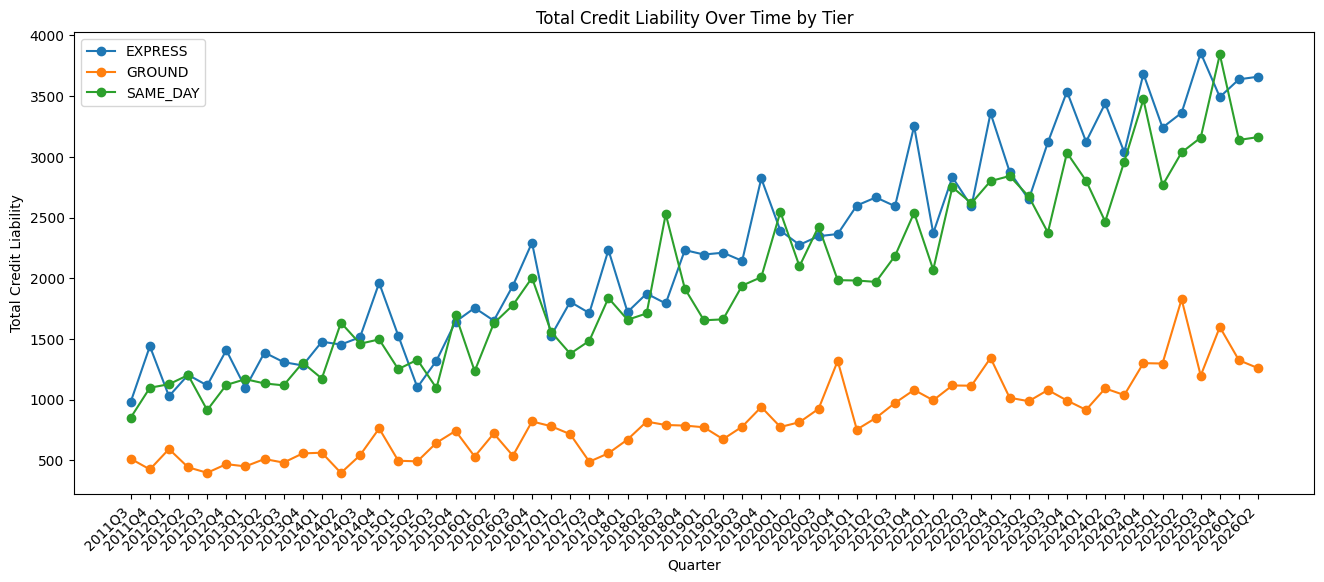

In [4]:
import matplotlib.pyplot as plt

gold_df['quarter'] = gold_df['quarter'].astype(str)  # converts quarter to string for plotting
current_quarter = pd.Timestamp.today().to_period('Q')
gold_quarterly_tier = gold_df[gold_df['quarter'].astype(str) != str(current_quarter)] # to exclude the current quarter from the plot
plt.figure(figsize=(16, 6))

for tier in gold_quarterly_tier['service_tier'].unique():
    tier_data = gold_quarterly_tier[gold_quarterly_tier['service_tier'] == tier]
    plt.plot(tier_data['quarter'], tier_data['total_credit_liability'], marker='o', label=tier)

plt.xticks(rotation=45, ha='right')
plt.title('Total Credit Liability Over Time by Tier')
plt.xlabel('Quarter')
plt.ylabel('Total Credit Liability')
plt.legend()
plt.show()

In [ ]:
quarters = gold_quarterly_tier['quarter'].unique()
cutoff_quarter = quarters[-4]  # quarter 4 from the end of the data

train_df = gold_quarterly_tier[gold_quarterly_tier['quarter'] < cutoff_quarter]
test_df = gold_quarterly_tier[gold_quarterly_tier['quarter'] >= cutoff_quarter]

print(train_df['quarter'].unique())
print(test_df['quarter'].unique())

<ArrowStringArray>
['2011Q3', '2011Q4', '2012Q1', '2012Q2', '2012Q3', '2012Q4', '2013Q1',
 '2013Q2', '2013Q3', '2013Q4', '2014Q1', '2014Q2', '2014Q3', '2014Q4',
 '2015Q1', '2015Q2', '2015Q3', '2015Q4', '2016Q1', '2016Q2', '2016Q3',
 '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2',
 '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1',
 '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4',
 '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3',
 '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2']
Length: 56, dtype: str
<ArrowStringArray>
['2025Q3', '2025Q4', '2026Q1', '2026Q2']
Length: 4, dtype: str


### Model 1: Naive Baseline (Same Quarter, Prior Year) - Quarterly Grain

In [6]:
# sanity check (naive baseline): for each tier, for each quarter in the test set, looks up the value from the same tier and quarter from the previous year (4 quarters ago) in the training set.
baseline_prediction_list = []
for tier in test_df['service_tier'].unique():
    for quarter in test_df['quarter'].unique():
        lookup_quarter = pd.Period(quarter, freq='Q') - 4
        last_year_value = train_df[(train_df['service_tier'] == tier) & (train_df['quarter'] == str(lookup_quarter))]
        baseline_prediction_list.append({
            'service_tier': tier,
            'quarter': quarter,
            'total_credit_liability_prediction': last_year_value['total_credit_liability'].values[0]
        })

In [7]:
baseline_prediction_df = pd.DataFrame(baseline_prediction_list)
baseline_prediction_df

,service_tier,quarter,total_credit_liability_prediction
0,EXPRESS,2025Q3,3037.400
1,EXPRESS,2025Q4,3684.315
2,EXPRESS,2026Q1,3241.220
3,EXPRESS,2026Q2,3362.710
4,GROUND,2025Q3,1037.235
5,GROUND,2025Q4,1300.155
6,GROUND,2026Q1,1297.060
7,GROUND,2026Q2,1826.595
8,SAME_DAY,2025Q3,2961.450
9,SAME_DAY,2025Q4,3473.305


In [8]:
key_col = ['service_tier', 'quarter']
baseline_results_df = pd.merge(test_df, baseline_prediction_df, on=key_col, how='left')
baseline_results_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,total_credit_liability_prediction
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,3037.400
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,1037.235
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,2961.450
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,3684.315
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,1300.155
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,3473.305
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,3241.220
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,1297.060
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,2764.680
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,3362.710


In [9]:
# calculates Mean Absolute Percentage Error for the baseline model
baseline_results_df['absolute_percentage_error'] = abs(baseline_results_df['total_credit_liability'] - baseline_results_df['total_credit_liability_prediction']) / baseline_results_df['total_credit_liability']
baseline_results_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,total_credit_liability_prediction,absolute_percentage_error
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,3037.400,0.212327
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,1037.235,0.133891
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,2961.450,0.062282
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,3684.315,0.054856
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,1300.155,0.186238
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,3473.305,0.096289
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,3241.220,0.109264
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,1297.060,0.020421
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,2764.680,0.119304
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,3362.710,0.081259


In [10]:
# calculates the average Mean Absolute Percentage Error for the baseline model
baseline_mape = baseline_results_df['absolute_percentage_error'].mean()
print(f"Baseline MAPE: {baseline_mape:.2%}") 

Baseline MAPE: 13.06%


### Model 2: Per-Tier Linear Regression (Trend Only) - Quarterly Grain

In [11]:
# builds a chronological ordering of all quarters (train + test combined), so both dfs share the same numeric timeline
all_quarters = pd.concat([train_df, test_df])['quarter'].unique()
all_quarters = sorted(all_quarters)  # chronological order

# maps each quarter string to its position in time: 0, 1, 2, ...
quarter_to_seq = {}
for i, q in enumerate(all_quarters):
    quarter_to_seq[q] = i

# applies mapping to both train and test sets
train_df['seq'] = train_df['quarter'].map(quarter_to_seq)
test_df['seq'] = test_df['quarter'].map(quarter_to_seq)

train_df[['quarter', 'seq']].drop_duplicates()

,quarter,seq
0,2011Q3,0
3,2011Q4,1
6,2012Q1,2
9,2012Q2,3
12,2012Q3,4
15,2012Q4,5
18,2013Q1,6
21,2013Q2,7
24,2013Q3,8
27,2013Q4,9


In [12]:
# builds a linear regression model for each tier, using the quarter sequence as the independent variable and total_credit_liability as the dependent variable
# predicts the total_credit_liability for each quarter in the test set
from sklearn.linear_model import LinearRegression

regression_prediction_list = []

for tier in train_df['service_tier'].unique():
    X = train_df[train_df['service_tier'] == tier][['seq']]
    y = train_df[train_df['service_tier'] == tier]['total_credit_liability']
    
    reg = LinearRegression().fit(X,y)
    predictions = reg.predict(test_df[test_df['service_tier'] == tier][['seq']])
    
    for quarter_row, pred_value in zip(test_df[test_df['service_tier'] == tier]['quarter'], predictions):
        regression_prediction_list.append({
            'service_tier': tier,
            'quarter': quarter_row,
            'prediction': pred_value
        })

In [13]:
regression_prediction_df = pd.DataFrame(regression_prediction_list)
regression_prediction_df

,service_tier,quarter,prediction
0,EXPRESS,2025Q3,3376.070380
1,EXPRESS,2025Q4,3419.426653
2,EXPRESS,2026Q1,3462.782925
3,EXPRESS,2026Q2,3506.139198
4,GROUND,2025Q3,1236.875571
5,GROUND,2025Q4,1252.433709
6,GROUND,2026Q1,1267.991846
7,GROUND,2026Q2,1283.549983
8,SAME_DAY,2025Q3,2965.893786
9,SAME_DAY,2025Q4,3003.210898


In [14]:
# calculates the Mean Absolute Percentage Error for the regression model
key_col = ['service_tier', 'quarter']
regression_results_df =pd.merge(test_df, regression_prediction_df, on=key_col, how='left')

regression_results_df['absolute_percentage_error'] = abs(regression_results_df['total_credit_liability'] - regression_results_df['prediction']) / regression_results_df['total_credit_liability']
regression_results_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,prediction,absolute_percentage_error
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,56,3376.070380,0.124502
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,56,1236.875571,0.032812
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,56,2965.893786,0.060875
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,57,3419.426653,0.020985
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,57,1252.433709,0.216107
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,57,3003.210898,0.218602
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,58,3462.782925,0.048375
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,58,1267.991846,0.042375
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,58,3040.528011,0.031432
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,59,3506.139198,0.042072


In [15]:
# calculates the average Mean Absolute Percentage Error for the regression model
regression_mape = regression_results_df['absolute_percentage_error'].mean()
print(f"Regression MAPE: {regression_mape:.2%}")

Regression MAPE: 7.37%


Between the regression and baseline model, neither model is universally better; the naive seasonal lookup wins on the tiers with strong seasonality, the regression wins on stabler tiers with a clear trend but weaker seasonality. Next step can be adding a seasonal feature to the regression to make it capture the trend.

### Model 3: Per-Tier Linear Regression (Trend + Seasonality) - Quarterly Grain

In [16]:
train_df['quarter_number'] = train_df['quarter'].apply(lambda x: pd.Period(x, freq='Q').quarter)
train_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,quarter_number
0,2011Q3,EXPRESS,2158,981.820,0.133457,0.261353,0.822408,51315.98,0,3
1,2011Q3,GROUND,6616,512.135,0.029625,0.179565,0.806178,129841.60,0,3
2,2011Q3,SAME_DAY,725,851.445,0.202759,0.343448,0.810249,23696.24,0,3
3,2011Q4,EXPRESS,2664,1439.590,0.148649,0.262012,0.813515,63823.41,1,4
4,2011Q4,GROUND,8875,424.645,0.029183,0.181972,0.799277,174885.79,1,4
...,...,...,...,...,...,...,...,...,...,...
163,2025Q1,GROUND,16485,1297.060,0.029421,0.184410,0.809860,457894.59,54,1
164,2025Q1,SAME_DAY,1853,2764.680,0.208851,0.308689,0.808464,82204.37,54,1
165,2025Q2,EXPRESS,5199,3362.710,0.150221,0.251010,0.811103,170854.04,55,2
166,2025Q2,GROUND,16795,1826.595,0.030962,0.187318,0.804504,468792.23,55,2


In [17]:
test_df['quarter_number'] = test_df['quarter'].apply(lambda x: pd.Period(x, freq='Q').quarter)
test_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,quarter_number
168,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,56,3
169,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,56,3
170,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,56,3
171,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,57,4
172,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,57,4
173,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,57,4
174,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,58,1
175,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,58,1
176,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,58,1
177,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,59,2


In [18]:
# one hot encodes the quarter_number column in train set
is_in_quarter_df = pd.get_dummies(train_df['quarter_number'], prefix='is_Q').astype(int)
train_df = pd.concat([train_df, is_in_quarter_df], axis=1)


In [19]:
# one hot encodes the quarter_number column in test set
is_in_quarter_df = pd.get_dummies(test_df['quarter_number'], prefix='is_Q').astype(int)
test_df = pd.concat([test_df, is_in_quarter_df], axis=1)

In [20]:
advanced_regression_prediction_list = []
for tier in train_df['service_tier'].unique():
    X = train_df[train_df['service_tier'] == tier][['seq', 'is_Q_1', 'is_Q_2', 'is_Q_3', 'is_Q_4']]
    y = train_df[train_df['service_tier'] == tier]['total_credit_liability']
    
    
    reg = LinearRegression().fit(X,y)
    predictions = reg.predict(test_df[test_df['service_tier'] == tier][['seq', 'is_Q_1', 'is_Q_2', 'is_Q_3', 'is_Q_4']])
    
    for quarter_row, pred_value in zip(test_df[test_df['service_tier'] == tier]['quarter'], predictions):
        advanced_regression_prediction_list.append({
            'service_tier': tier,
            'quarter': quarter_row,
            'prediction': pred_value
        })
    

In [21]:
advanced_regression_prediction_df = pd.DataFrame(advanced_regression_prediction_list)
advanced_regression_prediction_df

,service_tier,quarter,prediction
0,EXPRESS,2025Q3,3269.587170
1,EXPRESS,2025Q4,3697.796099
2,EXPRESS,2026Q1,3370.676099
3,EXPRESS,2026Q2,3440.640027
4,GROUND,2025Q3,1202.204856
5,GROUND,2025Q4,1330.408784
6,GROUND,2026Q1,1224.246284
7,GROUND,2026Q2,1284.796999
8,SAME_DAY,2025Q3,2962.396511
9,SAME_DAY,2025Q4,3146.426154


In [22]:
# calculates the Mean Absolute Percentage Error for the regression model
key_col = ['service_tier', 'quarter']
advanced_regression_results_df = pd.merge(test_df, advanced_regression_prediction_df, on=key_col, how='left')

advanced_regression_results_df['absolute_percentage_error'] = abs(advanced_regression_results_df['total_credit_liability'] - advanced_regression_results_df['prediction']) / advanced_regression_results_df['total_credit_liability']
advanced_regression_results_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,quarter_number,is_Q_1,is_Q_2,is_Q_3,is_Q_4,prediction,absolute_percentage_error
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,56,3,0,0,1,0,3269.587170,0.152115
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,56,3,0,0,1,0,1202.204856,0.003862
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,56,3,0,0,1,0,2962.396511,0.061982
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,57,4,0,0,0,1,3697.796099,0.058715
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,57,4,0,0,0,1,1330.408784,0.167303
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,57,4,0,0,0,1,3146.426154,0.181339
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,58,1,1,0,0,0,3370.676099,0.073687
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,58,1,1,0,0,0,1224.246284,0.075413
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,58,1,1,0,0,0,2969.458654,0.054072
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,59,2,0,1,0,0,3440.640027,0.059968


In [23]:
advanced_regression_results_df['absolute_percentage_error'] = abs(advanced_regression_results_df['total_credit_liability'] - advanced_regression_results_df['prediction']) / advanced_regression_results_df['total_credit_liability']
advanced_regression_results_df

,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,quarter_number,is_Q_1,is_Q_2,is_Q_3,is_Q_4,prediction,absolute_percentage_error
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,56,3,0,0,1,0,3269.587170,0.152115
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,56,3,0,0,1,0,1202.204856,0.003862
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,56,3,0,0,1,0,2962.396511,0.061982
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,57,4,0,0,0,1,3697.796099,0.058715
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,57,4,0,0,0,1,1330.408784,0.167303
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,57,4,0,0,0,1,3146.426154,0.181339
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,58,1,1,0,0,0,3370.676099,0.073687
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,58,1,1,0,0,0,1224.246284,0.075413
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,58,1,1,0,0,0,2969.458654,0.054072
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,59,2,0,1,0,0,3440.640027,0.059968


In [24]:
advanced_regression_results_df['absolute_percentage_error'].mean()
print(f"Advanced Regression MAPE: {advanced_regression_results_df['absolute_percentage_error'].mean():.2%}")

Advanced Regression MAPE: 7.93%


Trend-only regression (7.37%) narrowly beats the seasonal version (7.93%). A straight trend line captures most of the signal, and per-tier one-hot seasonal dummies estimated via ordinary least squares aren't the most efficient way to squeeze out the remaining seasonal signal.

### Model 4: Per-Tier Random Forest (Trend + Seasonality) - Quarterly Grain

In [ ]:
# to confirm whether a non-linear model could better capture the seasonal pattern the linear models struggled with
from sklearn.ensemble import RandomForestRegressor

rf_prediction_list = []
for tier in train_df['service_tier'].unique():
    X = train_df[train_df['service_tier'] == tier][['seq', 'is_Q_1', 'is_Q_2', 'is_Q_3', 'is_Q_4']]
    y = train_df[train_df['service_tier'] == tier]['total_credit_liability']

    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X, y)
    predictions = rf.predict(test_df[test_df['service_tier'] == tier][['seq', 'is_Q_1', 'is_Q_2', 'is_Q_3', 'is_Q_4']])

    for quarter_row, pred_value in zip(test_df[test_df['service_tier'] == tier]['quarter'], predictions):
        rf_prediction_list.append({'service_tier': tier, 'quarter': quarter_row, 'prediction': pred_value})

rf_prediction_df = pd.DataFrame(rf_prediction_list)
key_col = ['service_tier', 'quarter']
rf_results_df = pd.merge(test_df, rf_prediction_df, on=key_col, how='left')
rf_results_df['absolute_percentage_error'] = abs(rf_results_df['total_credit_liability'] - rf_results_df['prediction']) / rf_results_df['total_credit_liability']

rf_mape = rf_results_df['absolute_percentage_error'].mean()
print(f"Random Forest MAPE (Quarterly): {rf_mape:.2%}")
rf_results_df

Random Forest MAPE (Quarterly): 12.16%


,quarter,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,quarter_number,is_Q_1,is_Q_2,is_Q_3,is_Q_4,prediction,absolute_percentage_error
0,2025Q3,EXPRESS,5472,3856.170,0.152230,0.254020,0.804212,181884.19,56,3,0,0,1,0,3191.796875,0.172288
1,2025Q3,GROUND,17351,1197.580,0.028586,0.182698,0.808406,482789.35,56,3,0,0,1,0,1566.872325,0.308365
2,2025Q3,SAME_DAY,1960,3158.145,0.212755,0.332653,0.810521,88346.76,56,3,0,0,1,0,2975.962075,0.057687
3,2025Q4,EXPRESS,6228,3492.720,0.143545,0.258349,0.806057,208785.05,57,4,0,0,0,1,3597.986650,0.030139
4,2025Q4,GROUND,19876,1597.710,0.027772,0.181978,0.806088,559040.64,57,4,0,0,0,1,1591.958600,0.003600
5,2025Q4,SAME_DAY,2357,3843.380,0.219347,0.321595,0.801449,107478.74,57,4,0,0,0,1,3297.555450,0.142017
6,2026Q1,EXPRESS,5523,3638.810,0.142495,0.255115,0.815441,187401.23,58,1,1,0,0,0,3232.132800,0.111761
7,2026Q1,GROUND,17266,1324.100,0.029827,0.182497,0.813001,493399.67,58,1,1,0,0,0,1556.413400,0.175450
8,2026Q1,SAME_DAY,1914,3139.200,0.211599,0.322884,0.800000,88058.34,58,1,1,0,0,0,2954.515150,0.058832
9,2026Q2,EXPRESS,5694,3660.130,0.148226,0.259747,0.810597,193644.71,59,2,0,1,0,0,3362.756575,0.081247


### Feature Selection - Quarterly Grain

In [25]:
gold_quarterly_tier = gold_quarterly_tier.sort_values(['service_tier', 'quarter'])

gold_quarterly_tier['fda_rate_lag1'] = gold_quarterly_tier.groupby('service_tier')['avg_fda_rate'].shift(1)
gold_quarterly_tier['breach_rate_lag1'] = gold_quarterly_tier.groupby('service_tier')['breach_rate'].shift(1)
gold_quarterly_tier['guarantee_rate_lag1'] = gold_quarterly_tier.groupby('service_tier')['guarantee_attach_rate'].shift(1)

In [26]:
for tier in gold_quarterly_tier['service_tier'].unique():
    tier_data = gold_quarterly_tier[gold_quarterly_tier['service_tier'] == tier]
    cols = ['total_credit_liability', 'fda_rate_lag1', 'breach_rate_lag1', 'guarantee_rate_lag1', 'total_shipments']
    corr = tier_data[cols].corr()
    print(tier)
    print(corr['total_credit_liability'])
    print()

EXPRESS
total_credit_liability    1.000000
fda_rate_lag1            -0.011665
breach_rate_lag1          0.018621
guarantee_rate_lag1      -0.123234
total_shipments           0.973819
Name: total_credit_liability, dtype: float64

GROUND
total_credit_liability    1.000000
fda_rate_lag1             0.031755
breach_rate_lag1         -0.120895
guarantee_rate_lag1      -0.087217
total_shipments           0.909783
Name: total_credit_liability, dtype: float64

SAME_DAY
total_credit_liability    1.000000
fda_rate_lag1            -0.017667
breach_rate_lag1          0.019667
guarantee_rate_lag1      -0.094904
total_shipments           0.958397
Name: total_credit_liability, dtype: float64



Lagged operational features (FDA rate, breach rate, guarantee attach rate - each
shifted one quarter to avoid leakage) against `total_credit_liability` per tier, all
showed weak correlation (|r| < 0.13 across all tiers), while `total_shipments` showed very
strong correlation (0.91-0.97) - consistent with Models 2-3, where trend (`seq`, which
tracks growing volume over time) already captured most of the predictive signal.

**Conclusion:** Operational rate metrics (FDA, breach, guarantee attach) are relatively
stable quarter-to-quarter in this dataset and don't add meaningful predictive signal beyond
trend/volume.

## Monthly Grain Analysis

The models above run at quarterly grain (~60 data points per tier). Rebuilding the same pipeline
at monthly grain (~180 months of history) gives more training data per tier and tests whether the
extra resolution improves forecast accuracy, using the same train/test/MAPE methodology. This
section also adds a fourth model, Random Forest, and closes by summing the monthly predictions
back up to quarterly totals - the grain Finance actually consumes.

In [28]:
final_df['month'] = final_df['booking_timestamp'].dt.to_period('M')

gold_df_monthly = final_df.groupby(['month', 'service_tier']).agg(
    total_shipments=('shipment_id', 'count'),
    total_credit_liability=('credit_liability', 'sum'),
    breach_rate=('is_breached', lambda x: x.fillna(False).mean()),
    guarantee_attach_rate=('is_guaranteed', 'mean'),
    avg_fda_rate=('fda', 'mean'),
    total_billed=('total_billed', 'sum'),
).reset_index()

gold_df_monthly['month'] = gold_df_monthly['month'].astype(str)  # string grain keeps month sortable/joinable, same treatment as the quarterly 'quarter' column
current_month = pd.Timestamp.today().to_period('M')
gold_monthly_tier = gold_df_monthly[gold_df_monthly['month'] != str(current_month)]  # excludes the current in-progress month
gold_monthly_tier.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed
0,2011-07,EXPRESS,476,217.785,0.126050,0.268908,0.835443,11383.66
1,2011-07,GROUND,1548,169.380,0.032300,0.182171,0.780583,30906.30
2,2011-07,SAME_DAY,188,142.525,0.191489,0.292553,0.829787,6057.39
3,2011-08,EXPRESS,829,295.605,0.137515,0.242461,0.821040,19631.06
4,2011-08,GROUND,2616,152.115,0.027905,0.178899,0.809797,51733.25


In [29]:
months = sorted(gold_monthly_tier['month'].unique())
cutoff_month = months[-12]  # last 12 months held out as test

train_df_m = gold_monthly_tier[gold_monthly_tier['month'] < cutoff_month].copy()
test_df_m = gold_monthly_tier[gold_monthly_tier['month'] >= cutoff_month].copy()

print(train_df_m['month'].min(), '-', train_df_m['month'].max(), f'({len(train_df_m)} rows)')
print(test_df_m['month'].min(), '-', test_df_m['month'].max(), f'({len(test_df_m)} rows)')

2011-07 - 2025-06 (504 rows)
2025-07 - 2026-06 (36 rows)


### Model 1: Naive Baseline (Same Month, Prior Year) - Monthly Grain

In [30]:
# sanity check (naive baseline): for each tier, for each month in the test set, looks up
# the value from the same tier and month from the previous year (12 months ago) in the training set.
baseline_prediction_list_m = []
for tier in test_df_m['service_tier'].unique():
    for month in test_df_m['month'].unique():
        lookup_month = pd.Period(month, freq='M') - 12
        last_year_value = train_df_m[(train_df_m['service_tier'] == tier) & (train_df_m['month'] == str(lookup_month))]
        baseline_prediction_list_m.append({
            'service_tier': tier,
            'month': month,
            'total_credit_liability_prediction': last_year_value['total_credit_liability'].values[0]
        })

In [31]:
baseline_prediction_df_m = pd.DataFrame(baseline_prediction_list_m)
baseline_prediction_df_m.head()

,service_tier,month,total_credit_liability_prediction
0,EXPRESS,2025-07,892.185
1,EXPRESS,2025-08,1135.045
2,EXPRESS,2025-09,1010.170
3,EXPRESS,2025-10,1038.445
4,EXPRESS,2025-11,1479.030


In [32]:
# calculates the Mean Absolute Percentage Error for the baseline model
key_col_m = ['service_tier', 'month']
baseline_results_df_m = pd.merge(test_df_m, baseline_prediction_df_m, on=key_col_m, how='left')
baseline_results_df_m['absolute_percentage_error'] = abs(baseline_results_df_m['total_credit_liability'] - baseline_results_df_m['total_credit_liability_prediction']) / baseline_results_df_m['total_credit_liability']
baseline_results_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,total_credit_liability_prediction,absolute_percentage_error
0,2025-07,EXPRESS,1912,1303.770,0.139644,0.245293,0.810697,62646.95,892.185,0.315688
1,2025-07,GROUND,5915,309.825,0.027219,0.185292,0.802712,163342.18,400.825,0.293714
2,2025-07,SAME_DAY,647,978.020,0.208655,0.336940,0.810853,29055.78,1073.020,0.097135
3,2025-08,EXPRESS,1787,1252.365,0.162843,0.260772,0.796639,59801.29,1135.045,0.093679
4,2025-08,GROUND,5712,426.950,0.030987,0.176996,0.811347,157932.93,234.145,0.451587


In [33]:
# calculates the average Mean Absolute Percentage Error for the baseline model
baseline_mape_m = baseline_results_df_m['absolute_percentage_error'].mean()
print(f"Baseline MAPE (Monthly): {baseline_mape_m:.2%}")

Baseline MAPE (Monthly): 22.59%


### Model 2: Per-Tier Linear Regression (Trend Only) - Monthly Grain

In [34]:
# builds a chronological ordering of all months (train + test combined), so both dfs share the same numeric timeline
all_months = sorted(pd.concat([train_df_m, test_df_m])['month'].unique())
month_to_seq = {m: i for i, m in enumerate(all_months)}

train_df_m['seq'] = train_df_m['month'].map(month_to_seq)
test_df_m['seq'] = test_df_m['month'].map(month_to_seq)

train_df_m[['month', 'seq']].drop_duplicates().head()

,month,seq
0,2011-07,0
3,2011-08,1
6,2011-09,2
9,2011-10,3
12,2011-11,4


In [35]:
# builds a linear regression model for each tier, using the month sequence as the independent variable
# predicts the total_credit_liability for each month in the test set
from sklearn.linear_model import LinearRegression

regression_prediction_list_m = []
for tier in train_df_m['service_tier'].unique():
    X = train_df_m[train_df_m['service_tier'] == tier][['seq']]
    y = train_df_m[train_df_m['service_tier'] == tier]['total_credit_liability']

    reg = LinearRegression().fit(X, y)
    predictions = reg.predict(test_df_m[test_df_m['service_tier'] == tier][['seq']])

    for month_row, pred_value in zip(test_df_m[test_df_m['service_tier'] == tier]['month'], predictions):
        regression_prediction_list_m.append({'service_tier': tier, 'month': month_row, 'prediction': pred_value})

In [36]:
regression_prediction_df_m = pd.DataFrame(regression_prediction_list_m)
regression_prediction_df_m.head()

,service_tier,month,prediction
0,EXPRESS,2025-07,1121.139039
1,EXPRESS,2025-08,1125.963499
2,EXPRESS,2025-09,1130.787959
3,EXPRESS,2025-10,1135.612418
4,EXPRESS,2025-11,1140.436878


In [37]:
# calculates the Mean Absolute Percentage Error for the regression model
regression_results_df_m = pd.merge(test_df_m, regression_prediction_df_m, on=key_col_m, how='left')
regression_results_df_m['absolute_percentage_error'] = abs(regression_results_df_m['total_credit_liability'] - regression_results_df_m['prediction']) / regression_results_df_m['total_credit_liability']
regression_results_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,prediction,absolute_percentage_error
0,2025-07,EXPRESS,1912,1303.770,0.139644,0.245293,0.810697,62646.95,168,1121.139039,0.140079
1,2025-07,GROUND,5915,309.825,0.027219,0.185292,0.802712,163342.18,168,410.826400,0.325995
2,2025-07,SAME_DAY,647,978.020,0.208655,0.336940,0.810853,29055.78,168,984.972279,0.007109
3,2025-08,EXPRESS,1787,1252.365,0.162843,0.260772,0.796639,59801.29,169,1125.963499,0.100930
4,2025-08,GROUND,5712,426.950,0.030987,0.176996,0.811347,157932.93,169,412.558197,0.033708


In [38]:
# calculates the average Mean Absolute Percentage Error for the regression model
regression_mape_m = regression_results_df_m['absolute_percentage_error'].mean()
print(f"Trend-Only Regression MAPE (Monthly): {regression_mape_m:.2%}")

Trend-Only Regression MAPE (Monthly): 12.94%


### Model 3: Per-Tier Linear Regression (Trend + Seasonality) - Monthly Grain

In [39]:
train_df_m['month_number'] = train_df_m['month'].apply(lambda x: pd.Period(x, freq='M').month)
train_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,month_number
0,2011-07,EXPRESS,476,217.785,0.126050,0.268908,0.835443,11383.66,0,7
1,2011-07,GROUND,1548,169.380,0.032300,0.182171,0.780583,30906.30,0,7
2,2011-07,SAME_DAY,188,142.525,0.191489,0.292553,0.829787,6057.39,0,7
3,2011-08,EXPRESS,829,295.605,0.137515,0.242461,0.821040,19631.06,1,8
4,2011-08,GROUND,2616,152.115,0.027905,0.178899,0.809797,51733.25,1,8


In [40]:
test_df_m['month_number'] = test_df_m['month'].apply(lambda x: pd.Period(x, freq='M').month)
test_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,month_number
504,2025-07,EXPRESS,1912,1303.770,0.139644,0.245293,0.810697,62646.95,168,7
505,2025-07,GROUND,5915,309.825,0.027219,0.185292,0.802712,163342.18,168,7
506,2025-07,SAME_DAY,647,978.020,0.208655,0.336940,0.810853,29055.78,168,7
507,2025-08,EXPRESS,1787,1252.365,0.162843,0.260772,0.796639,59801.29,169,8
508,2025-08,GROUND,5712,426.950,0.030987,0.176996,0.811347,157932.93,169,8


In [41]:
# one hot encodes the month_number column in train set
train_month_dummies = pd.get_dummies(train_df_m['month_number'], prefix='is_M', prefix_sep='').astype(int)
train_df_m = pd.concat([train_df_m, train_month_dummies], axis=1)

In [42]:
# one hot encodes the month_number column in test set
test_month_dummies = pd.get_dummies(test_df_m['month_number'], prefix='is_M', prefix_sep='').astype(int)
test_df_m = pd.concat([test_df_m, test_month_dummies], axis=1)

month_dummy_cols = [f'is_M{i}' for i in range(1, 13)]
for col in month_dummy_cols:  # backfills any month-of-year missing from one split so both sides have all 12 columns
    if col not in train_df_m.columns:
        train_df_m[col] = 0
    if col not in test_df_m.columns:
        test_df_m[col] = 0

In [43]:
advanced_regression_prediction_list_m = []
for tier in train_df_m['service_tier'].unique():
    X = train_df_m[train_df_m['service_tier'] == tier][['seq'] + month_dummy_cols]
    y = train_df_m[train_df_m['service_tier'] == tier]['total_credit_liability']

    reg = LinearRegression().fit(X, y)
    predictions = reg.predict(test_df_m[test_df_m['service_tier'] == tier][['seq'] + month_dummy_cols])

    for month_row, pred_value in zip(test_df_m[test_df_m['service_tier'] == tier]['month'], predictions):
        advanced_regression_prediction_list_m.append({'service_tier': tier, 'month': month_row, 'prediction': pred_value})

In [44]:
advanced_regression_prediction_df_m = pd.DataFrame(advanced_regression_prediction_list_m)
advanced_regression_prediction_df_m.head()

,service_tier,month,prediction
0,EXPRESS,2025-07,1064.648104
1,EXPRESS,2025-08,1115.238819
2,EXPRESS,2025-09,1089.700247
3,EXPRESS,2025-10,1124.595604
4,EXPRESS,2025-11,1241.897033


In [45]:
# calculates the Mean Absolute Percentage Error for the regression model
advanced_regression_results_df_m = pd.merge(test_df_m, advanced_regression_prediction_df_m, on=key_col_m, how='left')
advanced_regression_results_df_m['absolute_percentage_error'] = abs(advanced_regression_results_df_m['total_credit_liability'] - advanced_regression_results_df_m['prediction']) / advanced_regression_results_df_m['total_credit_liability']
advanced_regression_results_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,month_number,...,is_M5,is_M6,is_M7,is_M8,is_M9,is_M10,is_M11,is_M12,prediction,absolute_percentage_error
0,2025-07,EXPRESS,1912,1303.770,0.139644,0.245293,0.810697,62646.95,168,7,...,0,0,1,0,0,0,0,0,1064.648104,0.183408
1,2025-07,GROUND,5915,309.825,0.027219,0.185292,0.802712,163342.18,168,7,...,0,0,1,0,0,0,0,0,383.311738,0.237188
2,2025-07,SAME_DAY,647,978.020,0.208655,0.336940,0.810853,29055.78,168,7,...,0,0,1,0,0,0,0,0,984.865385,0.006999
3,2025-08,EXPRESS,1787,1252.365,0.162843,0.260772,0.796639,59801.29,169,8,...,0,0,0,1,0,0,0,0,1115.238819,0.109494
4,2025-08,GROUND,5712,426.950,0.030987,0.176996,0.811347,157932.93,169,8,...,0,0,0,1,0,0,0,0,404.160666,0.053377


In [46]:
# calculates the average Mean Absolute Percentage Error for the regression model
advanced_regression_mape_m = advanced_regression_results_df_m['absolute_percentage_error'].mean()
print(f"Trend + Seasonality MAPE (Monthly): {advanced_regression_mape_m:.2%}")

Trend + Seasonality MAPE (Monthly): 12.46%


### Model 4: Per-Tier Random Forest (Trend + Seasonality) - Monthly Grain

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_prediction_list_m = []
for tier in train_df_m['service_tier'].unique():
    X = train_df_m[train_df_m['service_tier'] == tier][['seq'] + month_dummy_cols]
    y = train_df_m[train_df_m['service_tier'] == tier]['total_credit_liability']

    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X, y)
    predictions = rf.predict(test_df_m[test_df_m['service_tier'] == tier][['seq'] + month_dummy_cols])

    for month_row, pred_value in zip(test_df_m[test_df_m['service_tier'] == tier]['month'], predictions):
        rf_prediction_list_m.append({'service_tier': tier, 'month': month_row, 'prediction': pred_value})

In [48]:
rf_prediction_df_m = pd.DataFrame(rf_prediction_list_m)
rf_prediction_df_m.head()

,service_tier,month,prediction
0,EXPRESS,2025-07,1051.484150
1,EXPRESS,2025-08,1133.972525
2,EXPRESS,2025-09,1100.115750
3,EXPRESS,2025-10,1111.005425
4,EXPRESS,2025-11,1345.457325


In [49]:
# calculates the Mean Absolute Percentage Error for the Random Forest model
rf_results_df_m = pd.merge(test_df_m, rf_prediction_df_m, on=key_col_m, how='left')
rf_results_df_m['absolute_percentage_error'] = abs(rf_results_df_m['total_credit_liability'] - rf_results_df_m['prediction']) / rf_results_df_m['total_credit_liability']
rf_results_df_m.head()

,month,service_tier,total_shipments,total_credit_liability,breach_rate,guarantee_attach_rate,avg_fda_rate,total_billed,seq,month_number,...,is_M5,is_M6,is_M7,is_M8,is_M9,is_M10,is_M11,is_M12,prediction,absolute_percentage_error
0,2025-07,EXPRESS,1912,1303.770,0.139644,0.245293,0.810697,62646.95,168,7,...,0,0,1,0,0,0,0,0,1051.484150,0.193505
1,2025-07,GROUND,5915,309.825,0.027219,0.185292,0.802712,163342.18,168,7,...,0,0,1,0,0,0,0,0,541.478925,0.747693
2,2025-07,SAME_DAY,647,978.020,0.208655,0.336940,0.810853,29055.78,168,7,...,0,0,1,0,0,0,0,0,1023.620125,0.046625
3,2025-08,EXPRESS,1787,1252.365,0.162843,0.260772,0.796639,59801.29,169,8,...,0,0,0,1,0,0,0,0,1133.972525,0.094535
4,2025-08,GROUND,5712,426.950,0.030987,0.176996,0.811347,157932.93,169,8,...,0,0,0,1,0,0,0,0,540.366475,0.265643


In [50]:
# calculates the average Mean Absolute Percentage Error for the Random Forest model
rf_mape_m = rf_results_df_m['absolute_percentage_error'].mean()
print(f"Random Forest MAPE (Monthly): {rf_mape_m:.2%}")

Random Forest MAPE (Monthly): 18.73%


### Rolling Monthly Predictions Up to Quarterly Grain
Finance consumes quarterly numbers, not monthly ones. Sums each model's monthly predictions (and
actuals) within a quarter, then recomputes MAPE at quarterly grain to see how much accuracy survives
the roll-up.

In [51]:
def to_quarterly(results_df, pred_col):
    df = results_df[['month', 'service_tier', 'total_credit_liability', pred_col]].copy()
    df['quarter'] = df['month'].apply(lambda m: str(pd.Period(m, freq='M').asfreq('Q')))
    quarterly = df.groupby(['quarter', 'service_tier']).agg(
        total_credit_liability=('total_credit_liability', 'sum'),
        total_credit_liability_prediction=(pred_col, 'sum'),
    ).reset_index()
    quarterly['absolute_percentage_error'] = abs(quarterly['total_credit_liability'] - quarterly['total_credit_liability_prediction']) / quarterly['total_credit_liability']
    return quarterly

In [52]:
baseline_quarterly_m = to_quarterly(baseline_results_df_m, 'total_credit_liability_prediction')
regression_quarterly_m = to_quarterly(regression_results_df_m, 'prediction')
advanced_regression_quarterly_m = to_quarterly(advanced_regression_results_df_m, 'prediction')
rf_quarterly_m = to_quarterly(rf_results_df_m, 'prediction')

model_quarterly_mape = {
    'Naive Baseline': baseline_quarterly_m['absolute_percentage_error'].mean(),
    'Trend-Only Regression': regression_quarterly_m['absolute_percentage_error'].mean(),
    'Trend + Seasonality Regression': advanced_regression_quarterly_m['absolute_percentage_error'].mean(),
    'Random Forest': rf_quarterly_m['absolute_percentage_error'].mean(),
}
for name, mape in model_quarterly_mape.items():
    print(f"{name} MAPE (Monthly predictions summed to Quarterly): {mape:.2%}")

Naive Baseline MAPE (Monthly predictions summed to Quarterly): 13.06%
Trend-Only Regression MAPE (Monthly predictions summed to Quarterly): 7.34%
Trend + Seasonality Regression MAPE (Monthly predictions summed to Quarterly): 7.93%
Random Forest MAPE (Monthly predictions summed to Quarterly): 13.08%


In [53]:
quarterly_predictions_by_model = {
    'Naive Baseline': baseline_quarterly_m,
    'Trend-Only Regression': regression_quarterly_m,
    'Trend + Seasonality Regression': advanced_regression_quarterly_m,
    'Random Forest': rf_quarterly_m,
}
best_model_name = min(model_quarterly_mape, key=model_quarterly_mape.get)
print(f"Best model at quarterly grain after roll-up: {best_model_name} ({model_quarterly_mape[best_model_name]:.2%} MAPE)")

finance_facing_output = quarterly_predictions_by_model[best_model_name].sort_values(['quarter', 'service_tier']).reset_index(drop=True)
finance_facing_output

Best model at quarterly grain after roll-up: Trend-Only Regression (7.34% MAPE)


,quarter,service_tier,total_credit_liability,total_credit_liability_prediction,absolute_percentage_error
0,2025Q3,EXPRESS,3856.170,3377.890497,0.124030
1,2025Q3,GROUND,1197.580,1237.674590,0.033480
2,2025Q3,SAME_DAY,3158.145,2967.373177,0.060406
3,2025Q4,EXPRESS,3492.720,3421.310634,0.020445
4,2025Q4,GROUND,1597.710,1253.260763,0.215589
5,2025Q4,SAME_DAY,3843.380,3004.742199,0.218203
6,2026Q1,EXPRESS,3638.810,3464.730770,0.047840
7,2026Q1,GROUND,1324.100,1268.846936,0.041729
8,2026Q1,SAME_DAY,3139.200,3042.111220,0.030928
9,2026Q2,EXPRESS,3660.130,3508.150907,0.041523


### Model Comparison

| Model | Quarterly Grain (native) | Monthly Grain (native) | Monthly → Quarterly (summed) |
|---|---|---|---|
| Naive Baseline (prior year, same period) | 13.06% | 22.59% | 13.06% |
| Trend-Only Regression | 7.37% | 12.94% | **7.34%** |
| Trend + Seasonality Regression | 7.93% | 12.46% | 7.93% |
| Random Forest (trend + seasonality features) | 12.16% | 18.73% | 13.08% |

**Trend-Only Regression remains the best model overall**, at every grain it was tested at. Three
things stand out:

- **Monthly-native MAPE is worse than quarterly-native MAPE across every model.** Monthly credit
  liability is noisier (smaller sums, more variance quarter-to-quarter within the same tier), so
  errors that partially cancel out when aggregated to a quarter show up in full at monthly grain.
  Once summed back to quarterly, the regression models land almost exactly where the original
  quarterly-grain models did (7.34% vs. 7.37%, 7.93% vs. 7.93%) - the extra monthly resolution
  doesn't change what the regressions learn about trend/seasonality, it just adds noise to look at
  along the way.
- **Random Forest underperforms both regressions at every grain** (12.16% quarterly and 13.08%
  monthly-summed-to-quarterly vs. 7.34% for Trend-Only). Tree-based models predict by averaging
  training targets in a leaf and can't extrapolate a trend past the range they were trained on -
  since the test set is chronologically *after* all training data and credit liability has been
  trending upward, RF systematically under-predicts the newest periods. Linear regression's `seq`
  term extrapolates the trend correctly; RF's `seq` splits do not.
- **Random Forest is the only model where quarterly grain clearly beats monthly-summed-to-quarterly**
  (12.16% vs. 13.08%). With fewer, larger quarterly data points the trend is easier for RF's splits
  to approximate; at monthly grain the same extrapolation failure compounds over three predictions
  per quarter instead of one.

**Conclusion:** rebuilding at monthly grain and adding Random Forest were worth testing but don't
change the recommendation - Trend-Only Regression at quarterly grain stays the production model for
Finance's credit liability forecast.

This closes out the local R&D phase; next step is porting the pipeline to AWS, where DeepAR
in SageMaker will be evaluated as the production candidate, since it models trend and
seasonality jointly across related series rather than through hand-engineered per-tier
features.